# Summary - Process Trees EDA

### Build graph $G$ and find the connected components (process trees)
1. From the ```process_uber_summary``` table, build an ```igraph``` directed graph $G$ where each edge is of the form: ```parent PID --> child PID```
2. Get all (weak) connected components from $G$ -- those are the ```process trees``` (with one exception where a loop is present, which we drop), and save those in the **Trees** object
    * 99.98% of components are of size 2 (1,111,052  out of 1,111,278) ...
    * 210 process trees contain between 3 and 10k nodes
    * 15 have more then 10k nodes
3. Identify all process (sub)trees of size 3 to 10k inclusively ; store this info in a dataframe

### Scoring function
Enrich $G$ with metadata for each PID in the form of dictionaries:
* Pid -> process name
* Pid -> user name
* Pid -> embedding (from numerical features, done in a different notebook)
* process name -> frequeny
Those will be used to define various scoring functions, such as:
* binary match on process name
* binary match on process name and user name
* similarity in embedded space
* binary match on process name along with inverse process frequency score


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import seaborn as sns
from collections import Counter
import igraph as ig
import pickle
import gzip
import logging as lg
import re

## our matching algorithm
import sys
import os
sys.path.insert(0,os.path.abspath('../Matching'))
import igraph_io as igio
import gw_matcher as gwm ## older code - for testing
import fast_match as fm  ## fast version
import needleman_wunsch_tree as nwt ## slower, more flexibility for scoring functions

## several utility functions
import process_trees as pt


# Build process trees from the ```process_uber_summary``` table


In [3]:
process_summary = pd.read_parquet("Data/process_uber_summary.parquet", columns=['pid_hash', 'parent_pid_hash', 'process_name', 'user_name', 'red_team'] )
process_summary.head()


,pid_hash,parent_pid_hash,process_name,user_name,red_team
0,A86DB324303BBC24B4C279909AC5AD00,B066C89E8047845304C38E8BEE22AD90,powershell.exe,ACME\user10,1
1,C194ECED319F84EC8DAED02EE44FCE63,450735D5CC2CCEC4C8B12EC8818120E8,wmic.exe,None,0
2,FA50BB30E957D73120420F46B18AE167,450735D5CC2CCEC4C8B12EC8818120E8,wmic.exe,None,0
3,5803C60CEB8387DFA7ADA3E5E75E88FF,6FB634509A57999E72BCAFA74A8FFF29,wmic.exe,None,0
4,3BD26DAC90333D99453E9F506A514B1B,6FB634509A57999E72BCAFA74A8FFF29,wmic.exe,None,0


In [4]:
## we'll use those throughout
dct_username = dict(zip(process_summary.pid_hash,process_summary.user_name))
dct_label = dict(zip(process_summary.pid_hash,process_summary.red_team))
dct_processname = dict(zip(process_summary.pid_hash,process_summary.process_name))


In [5]:
def extract_process_trees(process, uid='pid_hash', parent_uid='parent_pid_hash', extra=None, min_tree_size=3, max_tree_size=100):
    """
    Build process trees given uid's and parent uid's. 

    Args:
        process: dataframe with (at least) uid and parent_uid columns
        uid, parent_uid: name of those columns in the dataframe
        extra: dictionary of extra columns to extract from the dataframe
        min_tree_size, max_tree_size: int

    Returns:
        igraph.clustering.VertexClustering
    """
    ## keep required columns
    df = process.drop_duplicates()
    
    ## parents and children
    child = set(df[uid])
    parent = set(df[parent_uid]) ## Can be 'None', we'll delete later
    
    ## node dictionaries
    nodes = parent.union(child)
    nodes_dict = {v:k for k,v in enumerate(nodes)}
    inv_nodes_dict = {k:v for k,v in enumerate(nodes)}

    ## build directed graph from edgelist
    child = [nodes_dict[x] for x in df[uid]]
    parent = [nodes_dict[x] for x in df[parent_uid]]
    edges = np.array([parent,child]).T
    G = ig.Graph.TupleList(edges, directed=True)
    G = G.simplify() ## there are self-edges
    G.vs['uid'] = [inv_nodes_dict[int(x)] for x in G.vs['name']]

    ## find all connected components a.k.a. process trees (with one exception)
    Trees = G.connected_components(mode="weak")
    G.vs['tree'] = Trees.membership

    ## drop trees of size < min_tree_size and non-tree(s)
    _dct = dict(enumerate(Trees.sizes()))
    G.vs['tree_size'] = [_dct[i] for i in G.vs['tree']]
    roots = np.where(np.array(G.degree(mode='in'))==0)
    non_tree = set(np.array(G.vs['tree'])).difference(set(np.array(G.vs['tree'])[roots]))
    G.delete_vertices([v for v in G.vs if (v['tree_size']<min_tree_size or v['tree_size']>max_tree_size or v['tree'] in non_tree)])

    ## re-compute 
    Trees = G.connected_components(mode="weak")
    G.vs['tree'] = Trees.membership
    del G.vs['name']

    ## add some node features
    if extra:
        for i, (feature,name) in enumerate(extra.items()):
            user_dict = dict(zip(df[uid],df[feature]))
            G.vs[name] = [user_dict.get(x, '') for x in G.vs['uid']]    
    return Trees



In [6]:
%%time
Trees = extract_process_trees(process=process_summary, uid='pid_hash', parent_uid='parent_pid_hash',
                              min_tree_size=3, max_tree_size=100000, 
                              extra={'process_name':'process','user_name':'user','red_team':'redteam'})


CPU times: user 14.6 s, sys: 514 ms, total: 15.1 s
Wall time: 15.1 s


In [7]:
## for plotting - red_team nodes in red
Trees.graph.vs['label_color'] = 'black'
Trees.graph.vs['color'] = 'black'
for v in Trees.graph.vs:
    if dct_label.get(v['uid'],0)>0:
        v['label_color']='red'
        v['color']='red'

In [8]:
len(Trees)

224

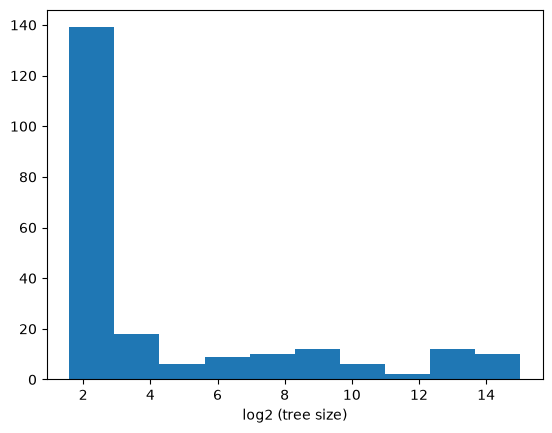

In [9]:
plt.hist([np.log2(x) for x in Trees.sizes()])
plt.xlabel('log2 (tree size)');


In [10]:
Trees.graph.vs[0]

igraph.Vertex(<igraph.Graph object at 0x79766b069650>, 0, {'uid': 'B066C89E8047845304C38E8BEE22AD90', 'tree': 0, 'tree_size': 23835, 'process': 'unknown', 'user': None, 'redteam': 1, 'label_color': 'red', 'color': 'red'})

## List all subtrees with known root process name


In [11]:

def acme_list_process_subtrees(G, process_name='process', min_tree_size=3):
    """
    ACME4 specific function - list all subtrees of a process tree where the root process is named
    """
    L = []

    for v in G.vs:
        process = v[process_name]
        if G.degree(v, mode='out')>0 and process != '' and process != 'unknown': ## pick non-leaf nodes with some process name
            V, l, p = G.bfs(v.index)
            nodes = len(V)
            splits = sum([x>1 for x in list(Counter(np.array(p)[np.array(p)>=0]).values())])
            if nodes<min_tree_size: 
                continue
            leaves = nodes - len(set(np.array(p)[np.array(p)>=0]))
            layers = len(l)-1

            ## acme specific
            b3 = len([dct_username.get(x,'') for x in G.vs[V]['uid'] if x is not None and 'baduser3' in x])
            b9 = len([dct_username.get(x,'') for x in G.vs[V]['uid'] if x is not None and 'baduser9' in x])
            b25 = len([dct_username.get(x,'') for x in G.vs[V]['uid'] if x is not None and 'baduser25' in x])
            red = sum([dct_label.get(x,0) for x in G.vs[V]['uid']])
            
            x = [v.index, process, nodes, layers, leaves, b3, b9, b25, red]
            L.append(x)

    return pd.DataFrame(L, columns=['root','process','nodes','layers','leaves','bad3','bad9','bad25','redteam'])


In [12]:
df_trees = pd.DataFrame()
for t in range(len(Trees)):
    _df = acme_list_process_subtrees(Trees.subgraph(t))
    _df.insert(loc=0, column='tree', value=t)
    df_trees = pd.concat([df_trees,_df])
df_trees


,tree,root,process,nodes,layers,leaves,bad3,bad9,bad25,redteam
0,0,2,ssm-agent-worker.exe,15904,3,15889,0,0,0,0
1,0,6,svchost.exe,769,3,761,0,0,0,0
2,0,39,ssm-document-worker.exe,4,2,3,0,0,0,0
3,0,52,svchost.exe,24,2,23,0,0,0,0
4,0,56,services.exe,22933,6,21039,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
1,183,4,conhost.exe,4,4,1,0,0,0,0
0,186,0,conhost.exe,3,3,1,0,0,0,0
0,188,2,conhost.exe,3,3,1,0,0,0,0
0,206,1,conhost.exe,3,3,1,0,0,0,0


In [13]:
## utility function - extract subtree from VertexClustering object
def acme_get_bfs_subtree(Trees, tree_id, root_id):
    """
    ACME4 specific function - extract a specific subtree 
    """    
    ## get subtree
    g = Trees.subgraph(tree_id)

    ## bfs ordering
    nodes, _ , parent = g.bfs(root_id)
    
    ## save vertices in new graph
    G = ig.Graph(directed=True)
    names = [str(g.vs['uid'][i]) for i in nodes] ## in BFS order
    G.add_vertices(names)
    
    ## save attributes in same order    
    for att in g.vs.attribute_names():
        G.vs[att] = [g.vs[att][i] for i in nodes]
    
    ## add edges
    E = [(str(g.vs['uid'][parent[i]]),str(g.vs['uid'][i])) for i in nodes if parent[i]>=0]
    G.add_edges(E)    

    del G.vs['name']
    
    return G


### Matching - define various weight functions

* default: exact match (between process names)
* invfreq: exact match weighted by each process' inverse frequency (log scale)
* embedded: exact match weighted by the process' distance in embedded space (built from numerical features)


In [14]:
from functools import partial
from scipy.spatial import distance

## default
def _def(a, b, _process):
    return int(_process[a]==_process[b])
w_default = partial(_def, _process=dct_processname)

## redblack
def _rb(a, b, _process, _label):
    return int(_process[a]==_process[b])*(_label[a]!=_label[b])
w_redblack = partial(_rb, _process=dct_processname, _label=dct_label)

## inverse frequency
proc_counts = Counter([dct_processname.get(v,'') for v in Trees.graph.vs['uid']])
dct_invfreq = {k: float(1/np.log2(v+1)) for k, v in proc_counts.items()} ## max score of 1 when v==1
def _if(a, b, _process, _freq):
    return int(_process[a]==_process[b])*(_freq[_process[a]])
w_invfreq = partial(_if, _process=dct_processname, _freq=dct_invfreq)

# embedded space
with gzip.open('Data/acme4_process_num_features_embedding_ecdf.pkl.gz', 'rb') as fp:
    embedding_ecdf = pickle.load(fp)
dim = len(next(iter(embedding_ecdf.values())))
def _es(a, b, _process, _emb):
    return int(_process[a]==_process[b])*(1-distance.cityblock(_emb[a],_emb[b])/dim)
    #return (1-distance.cityblock(_emb[a],_emb[b])/dim)
w_embed = partial(_es, _process=dct_processname, _emb=embedding_ecdf)


In [31]:
def plot_path(sg, path):
    sg.vs['vertex_size'] = 2
    sg.vs['vertex_label_size'] = 1
    for i in path:
        sg.vs[i]['vertex_size'] = 1
        sg.vs[i]['vertex_label_size'] = 20
    return ig.plot(sg, bbox=(1200,900), layout=sg.layout_reingold_tilford(), margin=150, 
            vertex_size=sg.vs['vertex_size'], 
            vertex_label=[dct_processname.get(x,'') for x in sg.vs['uid']],
            vertex_label_size=sg.vs['vertex_label_size'], 
            edge_color='lightgrey', edge_arrow_size=0)    

In [39]:
_df = df_trees[ (df_trees.layers>=8) & (df_trees.nodes<=500) ]
_trees = _df.tree.tolist()
_roots = _df.root.tolist()
_label = np.array(_df.redteam>0)


In [40]:
Counter(_label)

Counter({np.False_: 84, np.True_: 22})

In [41]:
TreeData = []
for (t,r) in zip(_trees,_roots):
    sg = acme_get_bfs_subtree(Trees, t, r) 
    TreeData.append(igio.igraph_to_treedata(sg, phi_name='uid'))


In [51]:
best_score = 0
min_red_nodes = 1

for red in np.where(_label==True)[0]:
    print(red)
    for black in np.where(_label==False)[0]:
        match = nwt.align_trees_algorithm1(TreeData[red], TreeData[black], w=w_embed)
        if match.score > best_score:
            red_nodes = sum([dct_label[TreeData[red].label[x[0]]] for x in match.path_internal])
            if red_nodes >= min_red_nodes: ## optional filter
                best_score = match.score
                best_pair = (red, black)
                print(best_score, best_pair)

35
0.9572483897209167 (np.int64(35), np.int64(41))
4.690844535827637 (np.int64(35), np.int64(64))
43
4.816667556762695 (np.int64(43), np.int64(12))
5.900731563568115 (np.int64(43), np.int64(14))
6.563540458679199 (np.int64(43), np.int64(39))
6.907818794250488 (np.int64(43), np.int64(64))
44
7.557794570922852 (np.int64(44), np.int64(39))
45
46
7.826830863952637 (np.int64(46), np.int64(39))
47
48
49
50
51
53
54
55
57
60
67
68
69
71
73
81
82


Score: 7.826830863952637
Tree size: 200


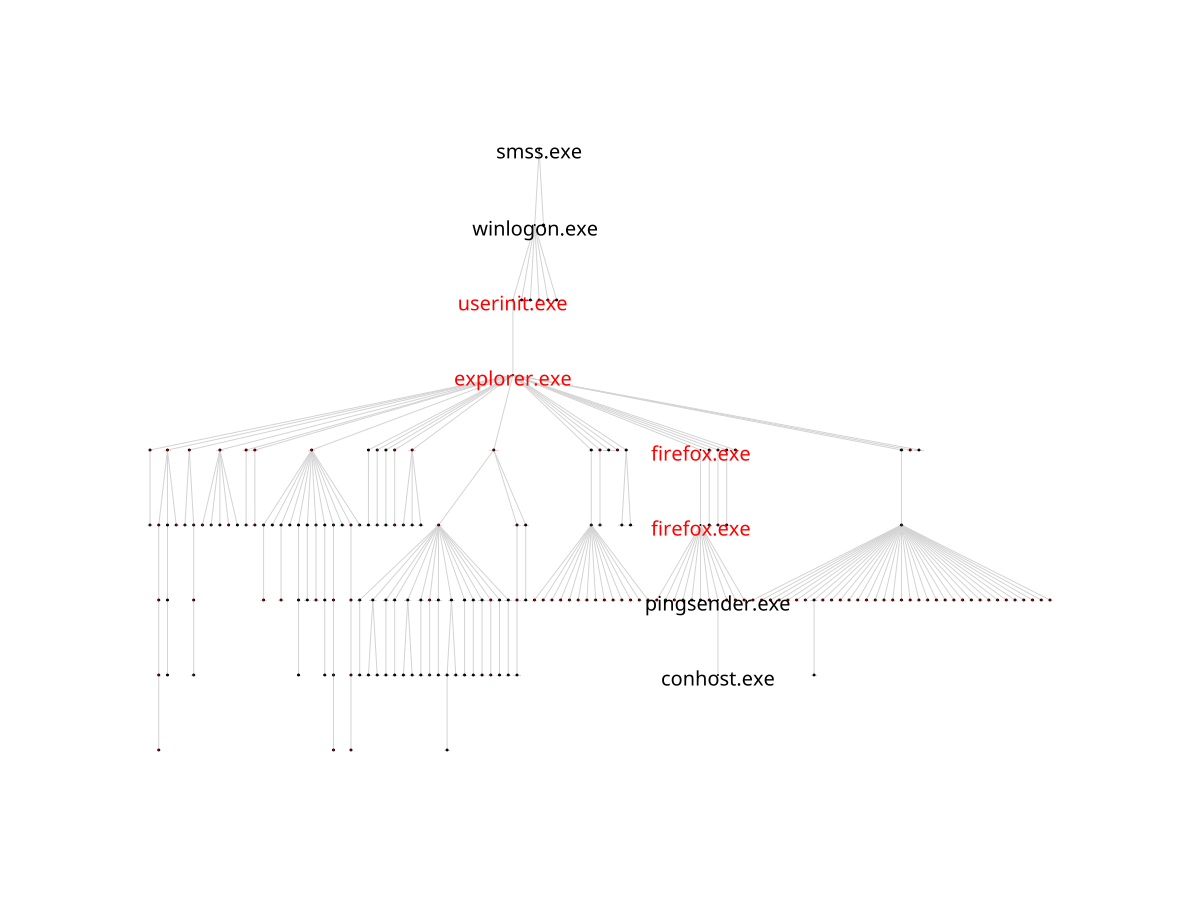

In [54]:
sg_red = acme_get_bfs_subtree(Trees, _trees[best_pair[0]], _roots[best_pair[0]]) 
sg_black = acme_get_bfs_subtree(Trees, _trees[best_pair[1]], _roots[best_pair[1]]) 
_sg_red = igio.igraph_to_treedata(sg_red, phi_name='uid')
_sg_black = igio.igraph_to_treedata(sg_black, phi_name='uid')

match = nwt.align_trees_algorithm1(_sg_red, _sg_black, w=w_embed)
print('Score:', match.score)
print('Tree size:', sg_red.vcount())
plot_path(sg_red, [x[0] for x in match.path_internal])


Tree size: 161


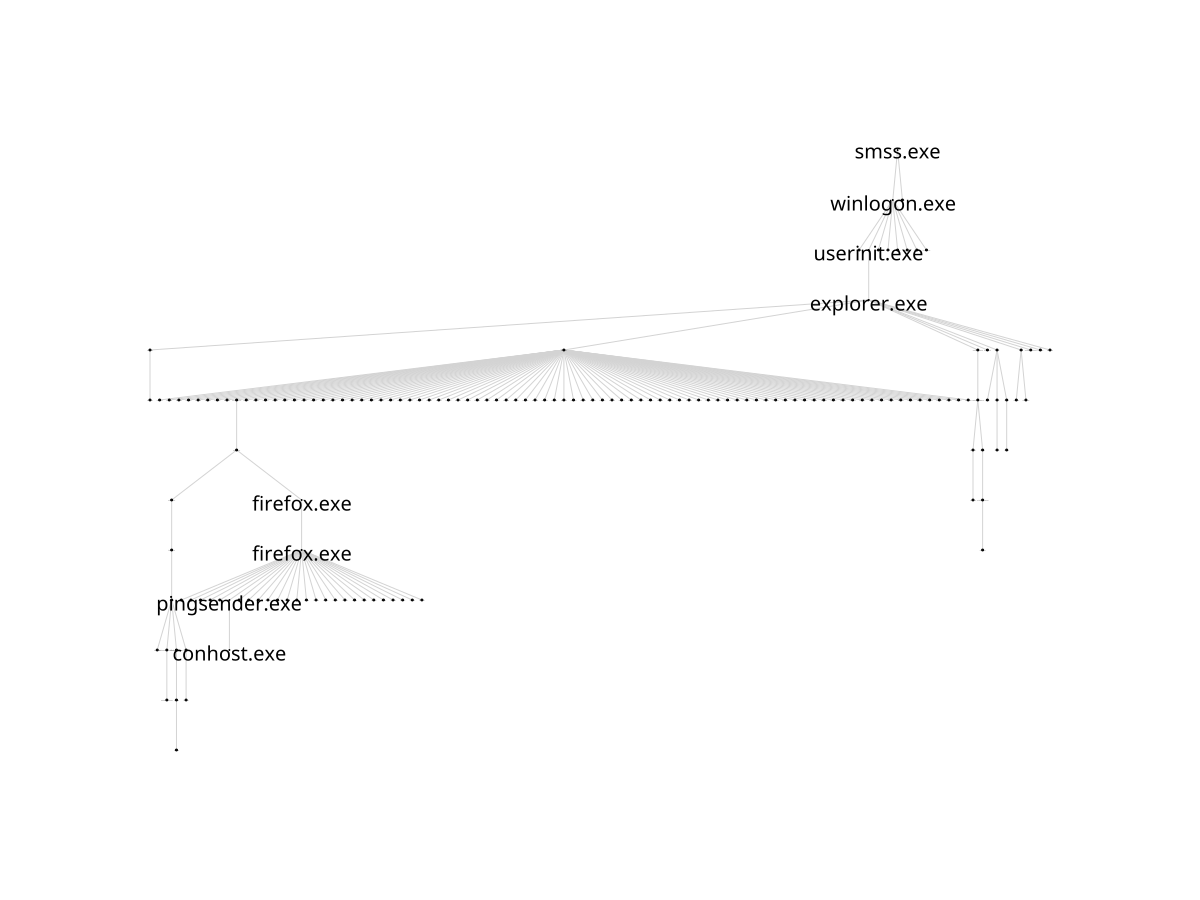

In [55]:
print('Tree size:', sg_black.vcount())
plot_path(sg_black, [x[1] for x in match.path_internal])


In [196]:
best_score = 0
for (rt,rr) in zip(_redtrees.tree,_redtrees.root):
    sg1 = acme_get_bfs_subtree(Trees, rt, rr) 
    _sg1 = igio.igraph_to_treedata(sg1, phi_name='uid')
    print(rt,rr)
    for (bt,br) in zip(_blacktrees.tree,_blacktrees.root):
        sg2 = acme_get_bfs_subtree(Trees, bt, br) 
        _sg2 = igio.igraph_to_treedata(sg1, phi_name='uid')
        match = nwt.align_trees_algorithm1(_sg1, _sg2, w=w_default)
        if match.score > best_score:
            best_score = match.score
            SG1 = sg1
            SG2 = sg2


12 545


KeyboardInterrupt: 

In [58]:
paths, score = gwm.basic_matcher(sg1, sg2, phi_name='newlabel', w=split_match) ## node feature == process name
score

np.float64(0.30566946388030813)

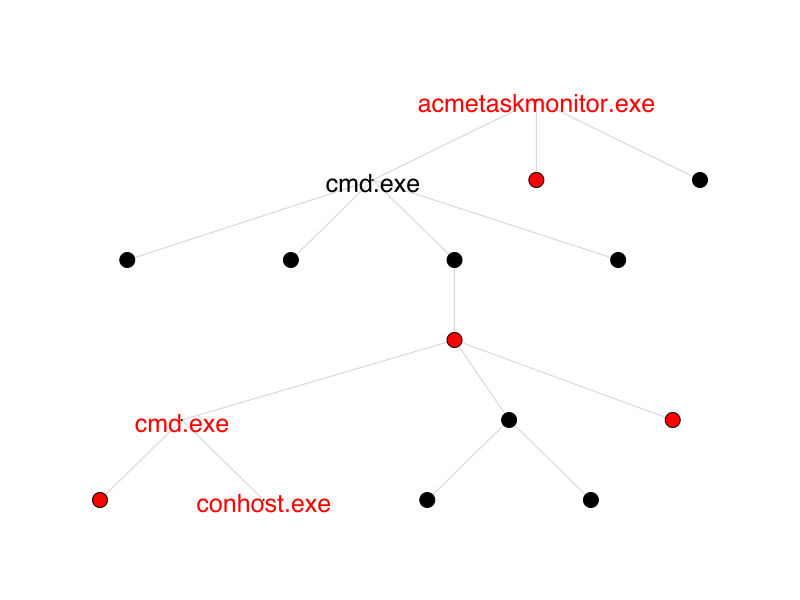

In [83]:
## pick one of the top hits and visualize common path (15 nodes, 7 layers)
tree = 36
root = 31
sg2 = acme_get_bfs_subtree(Trees, tree, root)
sg2.vs['newlabel'] = [_processname.get(x,'') for x in sg2.vs['uid']]
paths, score = gwm.basic_matcher(sg1, sg2, phi_name='newlabel', w=split_match) ## node feature == process name

## plot reference tree
path = [int(x[0]) for x in paths]
sg1.vs['vertex_size'] = 15
sg1.vs['vertex_label_size'] = 1
for i in path:
    sg1.vs[i]['vertex_size'] = 1
    sg1.vs[i]['vertex_label_size'] = 25
ig.plot(sg1, bbox=(800,600), layout=sg1.layout_reingold_tilford(), margin=100, 
        vertex_size=sg1.vs['vertex_size'], 
        vertex_label=[_processname.get(x,'') for x in sg1.vs['uid']],
        vertex_label_size=sg1.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


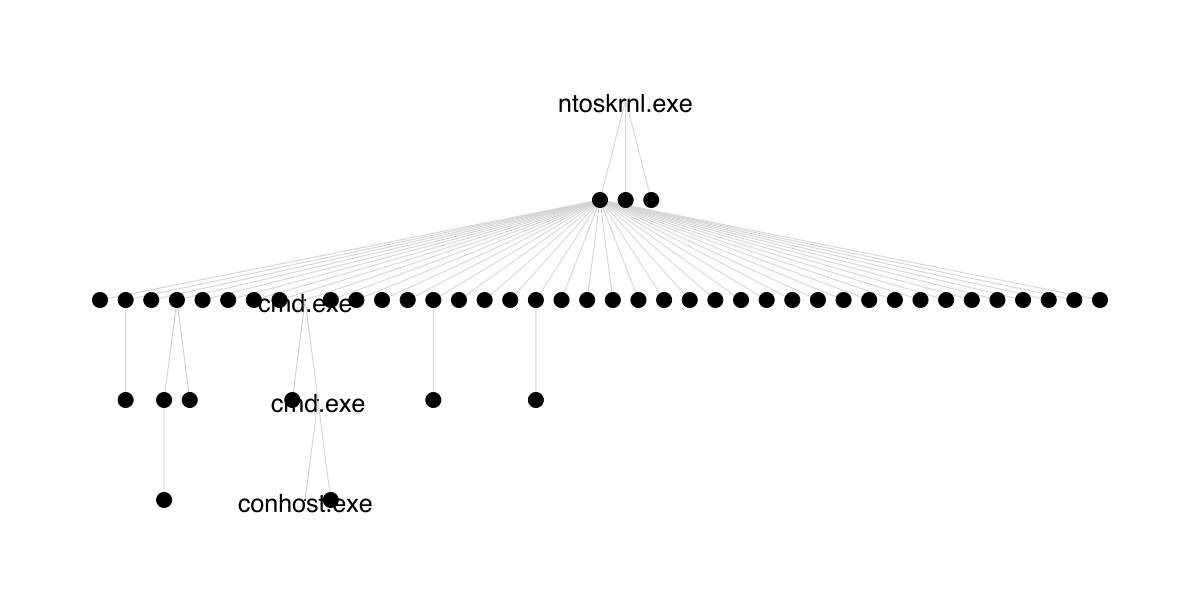

In [81]:
## plot top scoring tree
path = [int(x[1]) for x in paths]
sg2.vs['vertex_size'] = 15
sg2.vs['vertex_label_size'] = 1
for i in path:
    sg2.vs[i]['vertex_size'] = 1
    sg2.vs[i]['vertex_label_size'] = 25
ig.plot(sg2, 
        bbox=(1200,600), layout=sg2.layout_reingold_tilford(), margin=100, 
        vertex_size=sg2.vs['vertex_size'], 
        vertex_label=[_processname.get(x,'') for x in sg2.vs['uid']],
        vertex_label_size=sg2.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


In [256]:
[v for v in sg2.vs]

[igraph.Vertex(<igraph.Graph object at 0x7fadf55d6150>, 0, {'uid': 'E5ECF3CC867AF73D4AAA65509B789464', 'tree': 50, 'tree_size': 1031, 'label_color': 'black', 'vertex_color': 'black', 'newlabel': 'smss.exe', 'vertex_size': 1, 'vertex_label_size': 25}),
 igraph.Vertex(<igraph.Graph object at 0x7fadf55d6150>, 1, {'uid': '2596FF6053865E0B749041A29B1E6BD1', 'tree': 50, 'tree_size': 1031, 'label_color': 'black', 'vertex_color': 'black', 'newlabel': 'winlogon.exe', 'vertex_size': 15, 'vertex_label_size': 1}),
 igraph.Vertex(<igraph.Graph object at 0x7fadf55d6150>, 2, {'uid': 'E48D657328ACC887E40E4BB7E05E18BA', 'tree': 50, 'tree_size': 1031, 'label_color': 'black', 'vertex_color': 'black', 'newlabel': 'csrss.exe', 'vertex_size': 15, 'vertex_label_size': 1}),
 igraph.Vertex(<igraph.Graph object at 0x7fadf55d6150>, 3, {'uid': '63BB37E8D0540CEC020F3FB83FE15374', 'tree': 50, 'tree_size': 1031, 'label_color': 'black', 'vertex_color': 'black', 'newlabel': 'logonui.exe', 'vertex_size': 15, 'vertex_la

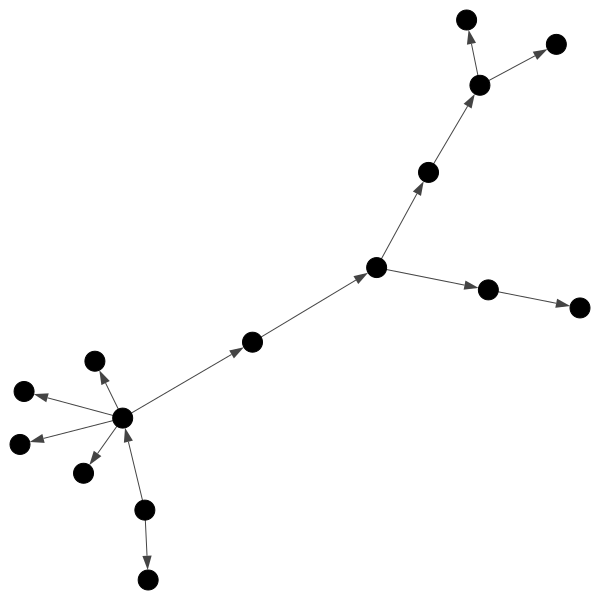

In [253]:
ig.plot(sg2, vertex_color = sg2.vs['vertex_color'])